In [1]:
from glob import glob
import os
import logging
logging.basicConfig(level=logging.INFO,format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logging.getLogger('pyogrio._io').setLevel(logging.WARNING)
logging.getLogger('distributed.core').setLevel(logging.WARNING)
logging.getLogger('distributed.scheduler').setLevel(logging.WARNING)
logging.getLogger('distributed.nanny').setLevel(logging.WARNING)
logging.getLogger('distributed.diskutils').setLevel(logging.WARNING)
logging.getLogger('distributed.http.proxy').setLevel(logging.WARNING)

import numpy as np
import matplotlib.pyplot as plt
import rasterio as rio
from dask import compute, delayed
from dask.distributed import Client
import time

from fire_impacts.pre.project import  initialise_project, find_all_shapefiles
from fire_impacts.pre.topography import extract_catchment_dems, extract_headwaters

2024-09-24 14:38:46,756 - numexpr.utils - INFO - Note: NumExpr detected 20 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
2024-09-24 14:38:46,757 - numexpr.utils - INFO - NumExpr defaulting to 8 threads.
C:\Users\jabbar.khaledi\AppData\Local\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,


In [2]:
HW_THRESHOLD=20000 # 20,000 m^2 (2ha)
WORKING_DIRECTORY=r''
DEM_PATH=r'' # Add path to DEM (eg to SRTM derived DEM-H)
CATCHMENT_SHAPEFILE_PATH=r'' # Path to a directory containing one or more shapefiles, each containing the boundary of a catchment of interest

### Get the catchment DEM (masking the SRTM DEM by the catchment shapefile)

In [3]:
fire_impacts_project = initialise_project(WORKING_DIRECTORY, find_all_shapefiles(CATCHMENT_SHAPEFILE_PATH), exist_ok=False,clear=True)
extract_catchment_dems(fire_impacts_project,DEM_PATH)

print('===================================================================================')
print(f'Masked DEMs were saved in {fire_impacts_project["Catchments_DEM"]} and Catchment_DEM folders')

2024-09-24 14:38:52,630 - fire_impacts.pre.topography - INFO - Extracting 2 catchment DEMs
2024-09-24 14:38:52,631 - fire_impacts.pre.topography - INFO - Extracting DEM for catchment: C:\Users\jabbar.khaledi\OneDrive - Alluvium Consulting Australia\Documents\Projects\WaterRA and bushfire modeling 0124114.10\Input\Shapefiles\DR_Primary_Catchment_Thomson.shp
2024-09-24 14:38:52,999 - rasterio._env - WARNING - CPLE_NotSupported in driver GTiff does not support creation option RES
2024-09-24 14:38:53,047 - rasterio._env - WARNING - CPLE_NotSupported in driver GTiff does not support creation option RES
2024-09-24 14:38:53,085 - fire_impacts.pre.topography - INFO - Extracting DEM for catchment: C:\Users\jabbar.khaledi\OneDrive - Alluvium Consulting Australia\Documents\Projects\WaterRA and bushfire modeling 0124114.10\Input\Shapefiles\Upper_Yarra.shp
2024-09-24 14:38:54,071 - rasterio._env - WARNING - CPLE_NotSupported in driver GTiff does not support creation option RES
2024-09-24 14:38:54,1

Masked DEMs were saved in C:\temp\Output/Topography/Catchments_DEM and Catchment_DEM folders


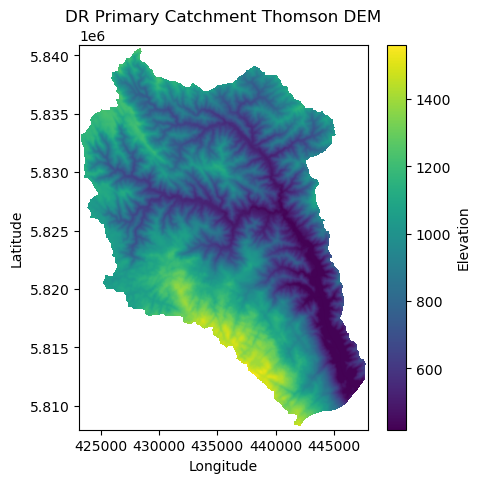

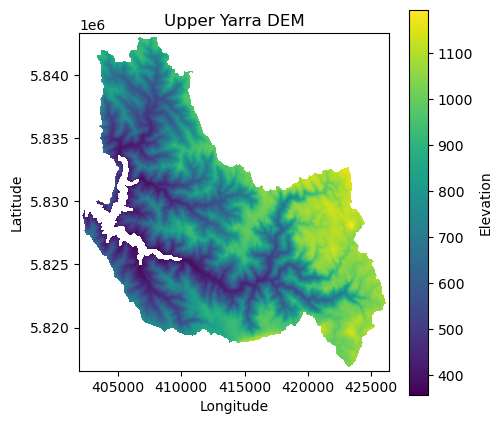

In [4]:
# Get the path to the 'Catchments_DEM' folder
catchments_dem_folder = fire_impacts_project['Catchments_DEM']
clipped_raster_paths = []
# Collecting all raster file paths
for root, dirs, files in os.walk(catchments_dem_folder):
    for file in files:
        if file.endswith('.tif'):
            raster_path = os.path.join(root, file)
            clipped_raster_paths.append(raster_path)
# Reading and plotting each raster file
for raster_path in clipped_raster_paths:
    with rio.open(raster_path) as src:
        data = src.read(1)
        no_data_value = src.nodata
        if no_data_value is not None:
            data = np.where(data == no_data_value, np.nan, data)  # Replace NoData values with NaN
        transform = src.transform
        # Extract the file name without extension for the plot title
        file_name = os.path.splitext(os.path.basename(raster_path))[0].replace('_', ' ')
        plt.figure(figsize=(5, 5))
        img = plt.imshow(data, cmap='viridis', extent=(
            transform[2], transform[2] + transform[0] * data.shape[1],
            transform[5] + transform[4] * data.shape[0], transform[5]
        ))
        plt.title(f'{file_name}', fontsize=12)
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        cbar = plt.colorbar(img, label='Elevation')
        plt.show()

### Import and list the catchment DEM files, and then delinate headwater (area=2 he)

In [5]:
# Initialize Dask client
client = Client()
extract_headwaters_d = delayed(extract_headwaters) # Create DASK version of function for running multip.e in parallel
# Create a list of delayed tasks
tasks = [extract_headwaters_d(fire_impacts_project,name,HW_THRESHOLD) for name in fire_impacts_project['Catchment_Names']]

In [6]:
st = time.time()

# Execute the tasks in parallel
results = compute(*tasks)

# Save all results into a dictionary
WHs_data = {name: hw_data for name, hw_data in results}
print('HWs are delineated and saved in the Topography/catch name/ HW_SHPs and HW_Rasters')

# get the end time
et = time.time()
elapsed_time_h = round((et - st) / 3600, 2)  # get the execution time
elapsed_time_m = round((et - st) / 60, 2)  # get the execution time
print('Execution time:', elapsed_time_h, 'hours')
print('Execution time:', elapsed_time_m, 'minutes')

HWs are delineated and saved in the Topography/catch name/ HW_SHPs and HW_Rasters
Execution time: 0.11 hours
Execution time: 6.66 minutes


In [7]:
WHs_data['DR_Primary_Catchment_Thomson']
#WHs_data['Upper_Yarra']

,ID,Area_m2,Area_ha,PourPt_X,PourPt_Y,Dist,Move_dist,X_EndP,Y_EndP
0,1,19641.0,2.0,428267.800244,5.840601e+06,213.5,175.0,428183.713165,5.840405e+06
1,2,19641.0,2.0,427959.480954,5.840433e+06,313.4,275.5,428015.539006,5.840124e+06
2,3,19641.0,2.0,428379.916349,5.840405e+06,196.2,196.2,428183.713165,5.840405e+06
3,4,19641.0,2.0,428379.916349,5.840405e+06,198.2,198.2,428267.800244,5.840237e+06
4,5,21998.0,2.2,428323.858297,5.840265e+06,62.7,67.7,428267.800244,5.840237e+06
...,...,...,...,...,...,...,...,...,...
6546,6547,21212.0,2.1,442114.139279,5.808620e+06,62.7,67.7,442170.197332,5.808648e+06
6547,6548,14927.0,1.5,441637.645830,5.808536e+06,115.6,67.7,441609.616804,5.808676e+06
6548,6549,20426.0,2.0,442114.139279,5.808564e+06,39.6,39.6,442142.168305,5.808592e+06
6549,6550,19641.0,2.0,442142.168305,5.808480e+06,112.1,56.1,442142.168305,5.808592e+06
